In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import EMNIST
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train = EMNIST(root='./data', train=True, download=True, transform=transform, split="balanced")
test = EMNIST(root='./data', train=False, download=True, transform=transform, split="balanced")


100%|██████████| 562M/562M [00:06<00:00, 82.2MB/s]


In [3]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 2

val_ratio = 0.1
val_size = int(len(train) * val_ratio)
train_size = len(train) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)


x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [4]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

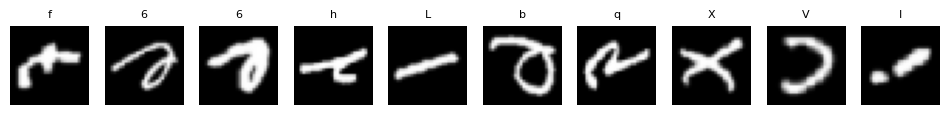

In [5]:
def show_images(loader, n: int = 10) -> None:
    class_names = train.classes
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [6]:
len(train.classes)

47

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (512, 256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 47])


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [10]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [11]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
            va_loss, va_acc = evaluate(model, val_loader, criterion, device)

            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["val_loss"].append(va_loss)
            history["val_acc"].append(va_acc)

            if verbose:
                print(
                    f"epoch {epoch:02d}/{epochs} | "
                    f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                    f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
                )


            if early_stopping is not None:
                should_stop = early_stopping.step(va_acc, model)
                if should_stop:
                    if verbose:
                        print(
                            f"EarlyStopping: остановка на эпохе {epoch}. "
                            f"Лучший val_acc={early_stopping.best_score:.4f}"
                        )
                    early_stopping.restore_best(model)
                    break
    return history

In [12]:
baseline = MLP(hidden_dims=(512, 256, 128), dropout_p=0.0, use_batchnorm=False).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)


epoch 01/20 | train loss=0.8652, acc=0.7302 | val loss=0.5956, acc=0.8044
epoch 02/20 | train loss=0.5085, acc=0.8264 | val loss=0.5075, acc=0.8334
epoch 03/20 | train loss=0.4291, acc=0.8474 | val loss=0.4704, acc=0.8410
epoch 04/20 | train loss=0.3842, acc=0.8605 | val loss=0.4988, acc=0.8390
epoch 05/20 | train loss=0.3502, acc=0.8697 | val loss=0.4838, acc=0.8407
epoch 06/20 | train loss=0.3223, acc=0.8783 | val loss=0.4762, acc=0.8482
epoch 07/20 | train loss=0.3020, acc=0.8848 | val loss=0.4934, acc=0.8484
epoch 08/20 | train loss=0.2830, acc=0.8894 | val loss=0.5119, acc=0.8471
epoch 09/20 | train loss=0.2690, acc=0.8949 | val loss=0.5479, acc=0.8386
epoch 10/20 | train loss=0.2574, acc=0.8987 | val loss=0.5462, acc=0.8439
epoch 11/20 | train loss=0.2458, acc=0.9029 | val loss=0.5876, acc=0.8415
epoch 12/20 | train loss=0.2380, acc=0.9059 | val loss=0.5899, acc=0.8447
epoch 13/20 | train loss=0.2292, acc=0.9088 | val loss=0.5958, acc=0.8444
epoch 14/20 | train loss=0.2200, acc=0

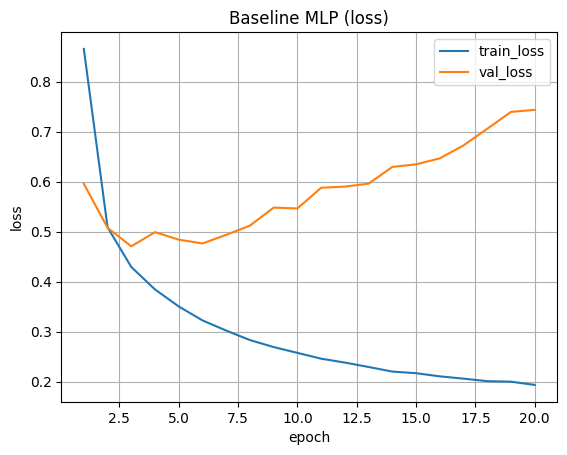

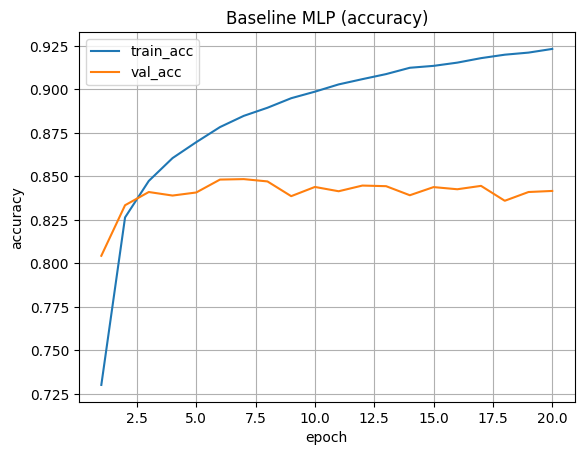

In [13]:
history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [14]:
test_loss_base, test_acc_base = evaluate(baseline, test_loader, criterion, device)
print(f"Baseline test: loss={test_loss_base:.4f}, acc={test_acc_base:.4f}")

Baseline test: loss=0.7841, acc=0.8328


epoch 01/20 | train loss=1.2443, acc=0.6281 | val loss=0.6992, acc=0.7749
epoch 02/20 | train loss=0.8319, acc=0.7369 | val loss=0.6009, acc=0.8073
epoch 03/20 | train loss=0.7528, acc=0.7573 | val loss=0.5544, acc=0.8197
epoch 04/20 | train loss=0.7116, acc=0.7672 | val loss=0.5405, acc=0.8237
epoch 05/20 | train loss=0.6825, acc=0.7758 | val loss=0.5240, acc=0.8270
epoch 06/20 | train loss=0.6700, acc=0.7789 | val loss=0.5056, acc=0.8322
epoch 07/20 | train loss=0.6529, acc=0.7835 | val loss=0.5114, acc=0.8299
epoch 08/20 | train loss=0.6402, acc=0.7876 | val loss=0.5106, acc=0.8283
epoch 09/20 | train loss=0.6303, acc=0.7888 | val loss=0.5005, acc=0.8331
epoch 10/20 | train loss=0.6186, acc=0.7934 | val loss=0.4913, acc=0.8345
epoch 11/20 | train loss=0.6129, acc=0.7936 | val loss=0.4884, acc=0.8383
epoch 12/20 | train loss=0.6073, acc=0.7956 | val loss=0.4912, acc=0.8347
epoch 13/20 | train loss=0.5976, acc=0.7989 | val loss=0.4938, acc=0.8386
epoch 14/20 | train loss=0.5999, acc=0

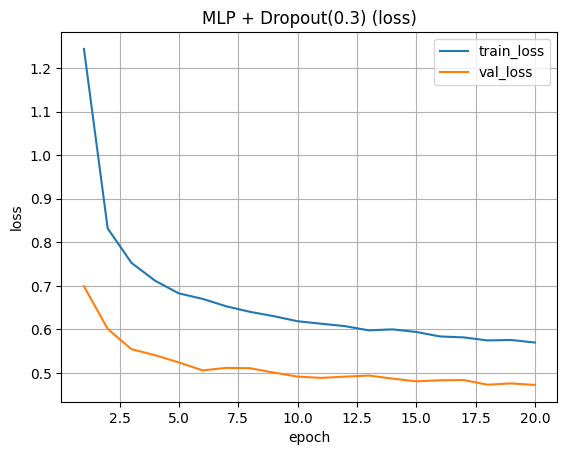

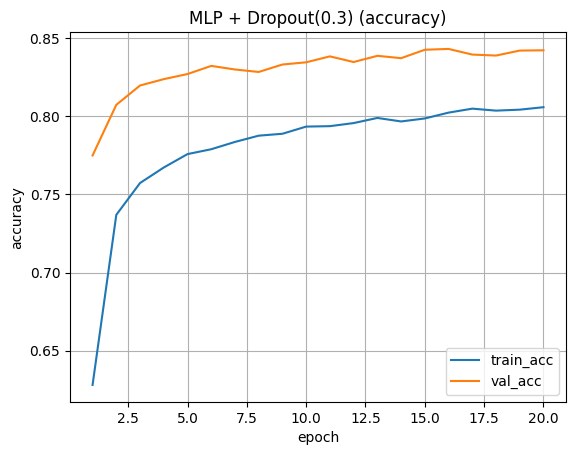

Dropout test: loss=0.4857, acc=0.8379


In [15]:
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss_drop, test_acc_drop = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss_drop:.4f}, acc={test_acc_drop:.4f}")

epoch 01/20 | train loss=0.8879, acc=0.7426 | val loss=0.5674, acc=0.8171
epoch 02/20 | train loss=0.5258, acc=0.8242 | val loss=0.4992, acc=0.8370
epoch 03/20 | train loss=0.4586, acc=0.8420 | val loss=0.4726, acc=0.8400
epoch 04/20 | train loss=0.4173, acc=0.8541 | val loss=0.4437, acc=0.8483
epoch 05/20 | train loss=0.3872, acc=0.8613 | val loss=0.4482, acc=0.8484
epoch 06/20 | train loss=0.3643, acc=0.8670 | val loss=0.4305, acc=0.8537
epoch 07/20 | train loss=0.3450, acc=0.8743 | val loss=0.4434, acc=0.8519
epoch 08/20 | train loss=0.3280, acc=0.8782 | val loss=0.4362, acc=0.8572
epoch 09/20 | train loss=0.3119, acc=0.8833 | val loss=0.4418, acc=0.8535
epoch 10/20 | train loss=0.3005, acc=0.8858 | val loss=0.4361, acc=0.8585
epoch 11/20 | train loss=0.2886, acc=0.8897 | val loss=0.4402, acc=0.8575
epoch 12/20 | train loss=0.2780, acc=0.8930 | val loss=0.4451, acc=0.8578
epoch 13/20 | train loss=0.2689, acc=0.8963 | val loss=0.4516, acc=0.8552
epoch 14/20 | train loss=0.2616, acc=0

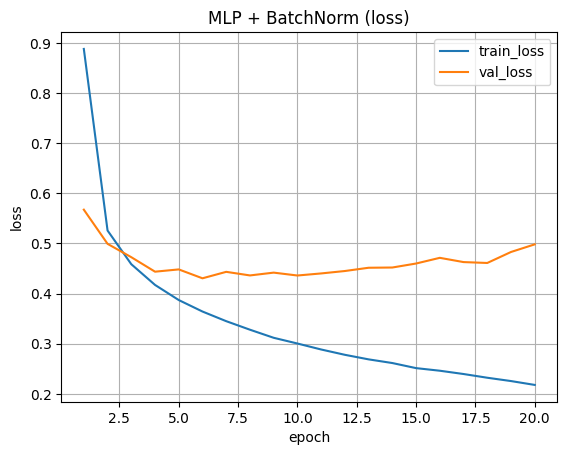

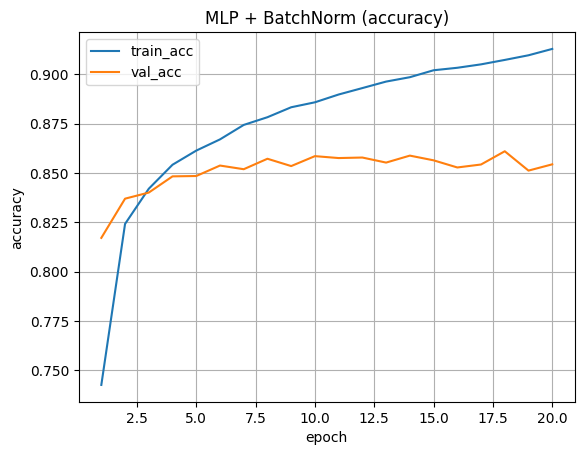

BatchNorm test: loss=0.5338, acc=0.8479


In [16]:
bn_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss_bn, test_acc_bn = evaluate(bn_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss_bn:.4f}, acc={test_acc_bn:.4f}")

epoch 01/50 | train loss=0.8875, acc=0.7425 | val loss=0.5583, acc=0.8173
epoch 02/50 | train loss=0.5279, acc=0.8240 | val loss=0.4982, acc=0.8372
epoch 03/50 | train loss=0.4577, acc=0.8417 | val loss=0.4628, acc=0.8438
epoch 04/50 | train loss=0.4165, acc=0.8541 | val loss=0.4511, acc=0.8501
epoch 05/50 | train loss=0.3897, acc=0.8598 | val loss=0.4414, acc=0.8539
epoch 06/50 | train loss=0.3655, acc=0.8670 | val loss=0.4369, acc=0.8543
epoch 07/50 | train loss=0.3453, acc=0.8731 | val loss=0.4390, acc=0.8545
epoch 08/50 | train loss=0.3273, acc=0.8783 | val loss=0.4375, acc=0.8541
epoch 09/50 | train loss=0.3126, acc=0.8834 | val loss=0.4356, acc=0.8558
epoch 10/50 | train loss=0.3006, acc=0.8862 | val loss=0.4490, acc=0.8539
epoch 11/50 | train loss=0.2896, acc=0.8898 | val loss=0.4342, acc=0.8581
epoch 12/50 | train loss=0.2799, acc=0.8925 | val loss=0.4441, acc=0.8550
epoch 13/50 | train loss=0.2698, acc=0.8955 | val loss=0.4448, acc=0.8550
epoch 14/50 | train loss=0.2600, acc=0

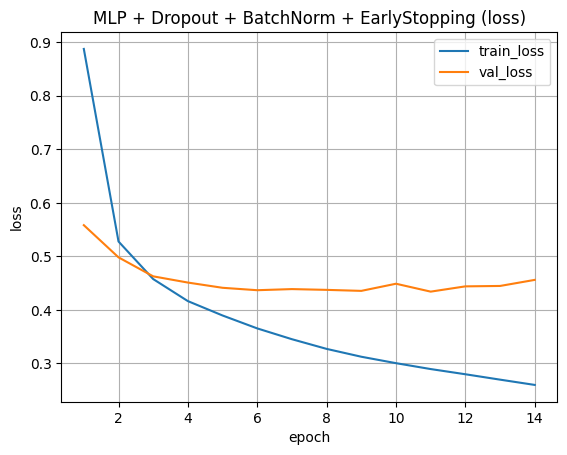

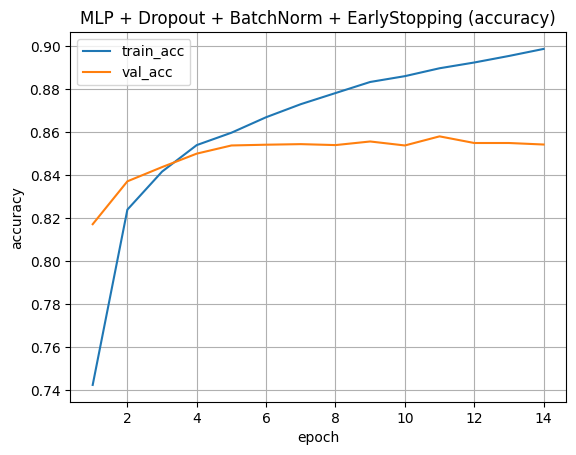

Combo test: loss=0.4660, acc=0.8528


In [17]:
combo_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=3, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="MLP + Dropout + BatchNorm + EarlyStopping")
test_loss_combo, test_acc_combo = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss_combo:.4f}, acc={test_acc_combo:.4f}")

In [18]:
torch.save(combo_model.state_dict(), 'best_model.pt')

In [33]:
import json

best_config = {
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': 42,

    'architecture': {
        'model_type': 'MLP',
        'hidden_sizes': [256, 128],
        'activation': 'ReLU',
        'dropout': 0.0,
        'batchnorm': True
    },


    'optimizer': 'Adam',
    'lr': 1e-33,
    'momentum': 0.0,
    'weight_decay': 0.0000,
    'batch_size': 64,
    'epochs_trained': 14,

    'best_val_accuracy': 0.8528,
    'best_val_loss': 0.4660,

    'weights_file': 'best_model.pt'
}

with open('best_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)

print("best_config.json сохранен!")

best_config.json сохранен!


In [30]:
def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

In [29]:
EPOCHS = 8
def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.0, epochs=EPOCHS):
    model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, device, epochs=epochs, verbose=True)

    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

lr_sweep = [
    ("LR_high", 1e-1),
    ("LR_low",  1e-5),
]


Experiment LR_high: Adam lr=0.1
epoch 01/8 | train loss=1.1737, acc=0.6462 | val loss=0.8476, acc=0.7410
epoch 02/8 | train loss=0.8717, acc=0.7271 | val loss=0.7454, acc=0.7624
epoch 03/8 | train loss=0.7987, acc=0.7480 | val loss=0.8062, acc=0.7571
epoch 04/8 | train loss=0.7569, acc=0.7597 | val loss=0.6617, acc=0.7874
epoch 05/8 | train loss=0.7201, acc=0.7684 | val loss=0.6662, acc=0.7907
epoch 06/8 | train loss=0.6975, acc=0.7757 | val loss=0.6928, acc=0.7938
epoch 07/8 | train loss=0.6694, acc=0.7824 | val loss=0.6911, acc=0.7774
epoch 08/8 | train loss=0.6569, acc=0.7886 | val loss=0.6507, acc=0.7961


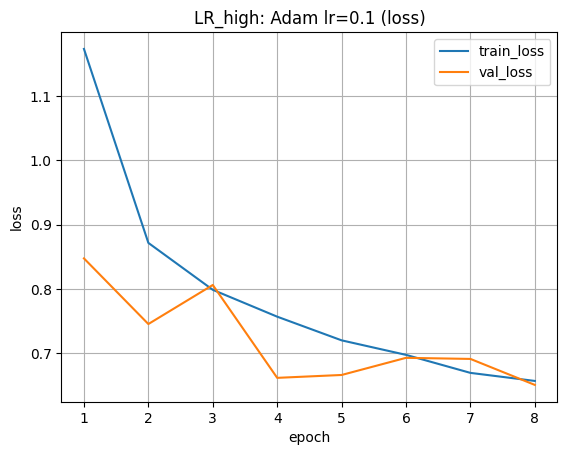

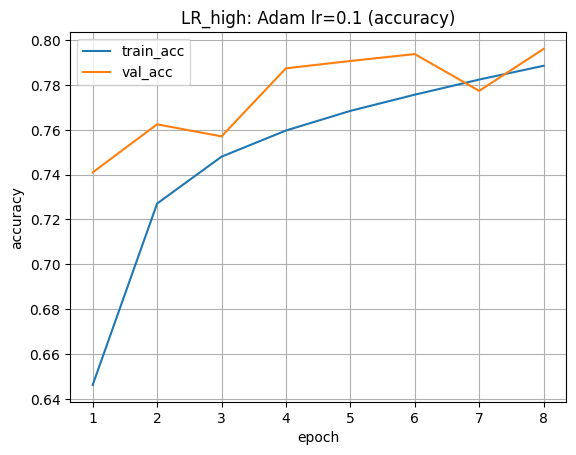


Experiment LR_low: Adam lr=1e-05
epoch 01/8 | train loss=3.2680, acc=0.2737 | val loss=2.8277, acc=0.4406
epoch 02/8 | train loss=2.6044, acc=0.5010 | val loss=2.3615, acc=0.5604
epoch 03/8 | train loss=2.2173, acc=0.5806 | val loss=2.0465, acc=0.6122
epoch 04/8 | train loss=1.9211, acc=0.6247 | val loss=1.7738, acc=0.6458
epoch 05/8 | train loss=1.6906, acc=0.6541 | val loss=1.5688, acc=0.6705
epoch 06/8 | train loss=1.5058, acc=0.6789 | val loss=1.4066, acc=0.6943
epoch 07/8 | train loss=1.3586, acc=0.6984 | val loss=1.2762, acc=0.7118
epoch 08/8 | train loss=1.2392, acc=0.7141 | val loss=1.1744, acc=0.7236


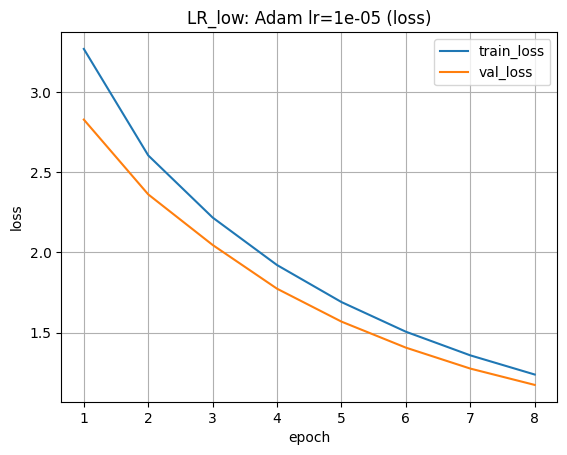

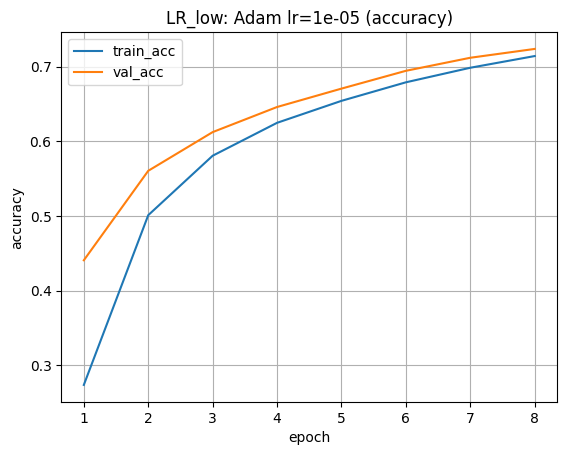

In [31]:
results_lr = []
for name, lr in lr_sweep:
    print("\n" + "="*80)
    print(f"Experiment {name}: Adam lr={lr}")
    res = run_experiment(exp_id=name, optimizer_kind="adam", lr=lr)
    results_lr.append(res)
    plot_history(res["history"], title=f"{name}: Adam lr={lr}")

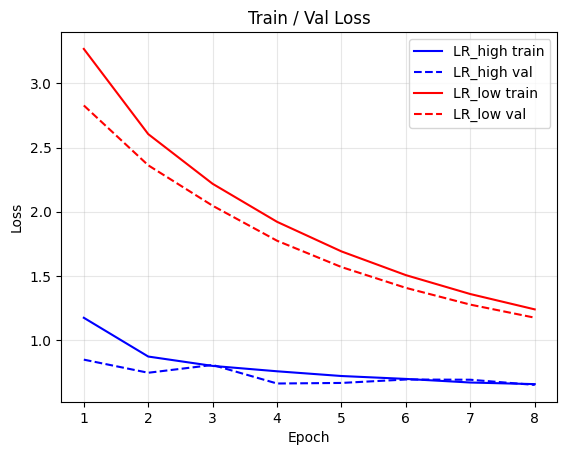

In [32]:
model1_id = 'LR_high'
model2_id = 'LR_low'


exp1 = None
exp2 = None
for r in results_lr:
    if r['exp_id'] == model1_id:
        exp1 = r
    if r['exp_id'] == model2_id:
        exp2 = r

epochs = range(1,9)
plt.plot(epochs, exp1['history']['train_loss'], 'b-', label=f'{model1_id} train')
plt.plot(epochs, exp1['history']['val_loss'], 'b--', label=f'{model1_id} val')
plt.plot(epochs, exp2['history']['train_loss'], 'r-', label=f'{model2_id} train')
plt.plot(epochs, exp2['history']['val_loss'], 'r--', label=f'{model2_id} val')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train / Val Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('loss_plot.png', dpi=300)
plt.show()

In [42]:
for r in results_lr:
    if r['exp_id'] == model1_id:
        best_val_acco1, best_val_losso1 = r['best_val_acc'], r['best_val_loss']
    if r['exp_id'] == model2_id:
        best_val_acco2, best_val_losso2 = r['best_val_acc'], r['best_val_loss']


epoch 01/10 | train loss=1.8844, acc=0.5718 | val loss=1.0888, acc=0.7196
epoch 02/10 | train loss=0.9260, acc=0.7474 | val loss=0.7618, acc=0.7813
epoch 03/10 | train loss=0.7071, acc=0.7915 | val loss=0.6422, acc=0.8091
epoch 04/10 | train loss=0.6070, acc=0.8143 | val loss=0.5793, acc=0.8220
epoch 05/10 | train loss=0.5463, acc=0.8284 | val loss=0.5438, acc=0.8325
epoch 06/10 | train loss=0.5060, acc=0.8386 | val loss=0.5256, acc=0.8310
epoch 07/10 | train loss=0.4758, acc=0.8467 | val loss=0.5086, acc=0.8375
epoch 08/10 | train loss=0.4505, acc=0.8514 | val loss=0.4920, acc=0.8418
epoch 09/10 | train loss=0.4296, acc=0.8579 | val loss=0.4902, acc=0.8398
epoch 10/10 | train loss=0.4139, acc=0.8617 | val loss=0.4787, acc=0.8457


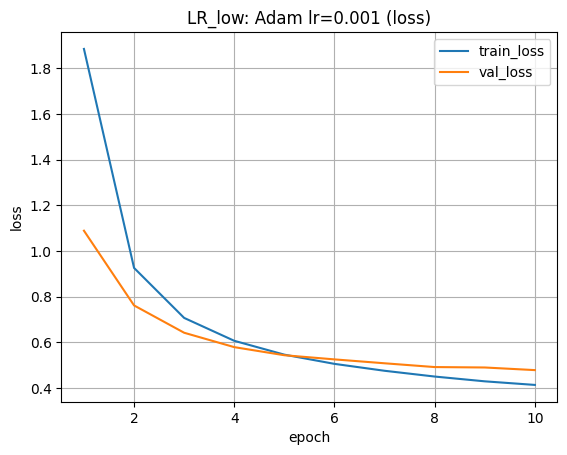

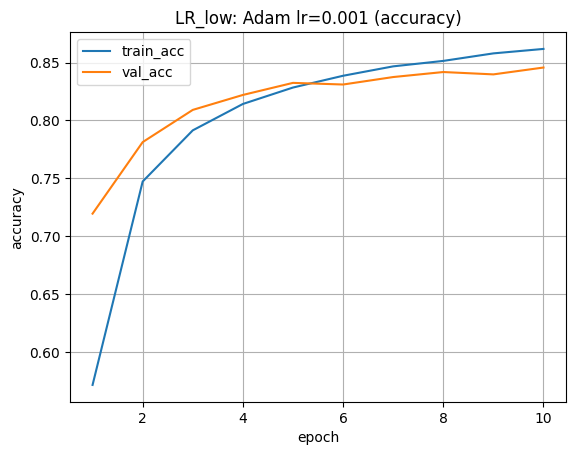

In [46]:
res = run_experiment(exp_id='SGD', optimizer_kind="sgd", lr=1e-3, weight_decay=1e-4, momentum=0.9, epochs=10)
plot_history(res["history"], title=f"{name}: Adam lr={1e-3}")

In [47]:
best_val_acc, best_val_loss = res['best_val_acc'], res['best_val_loss']

In [48]:
import csv

filename = 'runs.csv'

with open(filename, 'w', newline='') as f:
    writer = csv.writer(f)

    writer.writerow([
        'experiment_id', 'dataset', 'seed', 'model_summary',
        'optimizer', 'lr', 'momentum', 'weight_decay',
        'epochs_trained', 'best_val_accuracy', 'best_val_loss'
    ])

    writer.writerow(['E1', 'EMNIST', 42, 'hidden sizes:512,256,128;activation:relu;dropout:0.0;batchnorm:False', 'Adam', 1e-3, 0.0, 0.0, 20, test_acc_base, test_loss_base])

    writer.writerow(['E2', 'EMNIST', 42, 'hidden sizes:256,128;activation:relu;dropout:0.3;batchnorm:False', 'Adam', 1e-3, 0.0, 0.0, 20, test_acc_drop, test_loss_drop])

    writer.writerow(['E3', 'EMNIST', 42, 'hidden sizes:256,128;activation:relu;dropout:0.0;batchnorm:True', 'Adam', 1e-3, 0.0, 0.0, 20, test_acc_bn, test_loss_bn])

    writer.writerow(['E4', 'EMNIST', 42, 'hidden sizes:256,128;activation:relu;dropout:0.0;batchnorm:True', 'Adam', 1e-3, 0.0, 0.0, 14, test_acc_combo, test_loss_combo])

    writer.writerow(['O1', 'EMNIST', 42, 'hidden sizes:256,128;activation:relu;dropout:0.0;batchnorm:False', 'Adam', 1e-1, 0.0, 0.0, 8, best_val_acco1, best_val_losso1])


    writer.writerow(['O2', 'EMNIST', 42, 'hidden sizes:256,128;activation:relu;dropout:0.0;batchnorm:False', 'Adam', 1e-5, 0.0, 0.0, 8, best_val_acco2, best_val_losso2])

    writer.writerow(['O3', 'EMNIST', 42, 'hidden sizes:256,128;activation:relu;dropout:0.0;batchnorm:False', 'sgd', 1e-3, 0.9, 1e-4, 10, best_val_acc, best_val_loss])


print(f" Файл {filename} успешно создан!")

 Файл runs.csv успешно создан!
